<a href="https://colab.research.google.com/github/nomanabdullah04/MaChineLearning/blob/main/polynomial_regre.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**In this session we will discuss about Polynomial Regession.**

---
Polynomial regression is a form of regression analysis in machine learning where the relationship between the independent variable \(x) and the dependent variable (y) is modeled as an (n)-th degree polynomial. Unlike linear regression, which fits a straight line, polynomial regression curves the line to better fit data points that have a non-linear relationship.

2. Visually Understanding the CurveTo see how polynomial curves adapt compared to standard linear regression, we can visualize a 2nd-degree polynomial (quadratic function \(y = ax^2 + bx + c\)) fitting a set of curved data points:
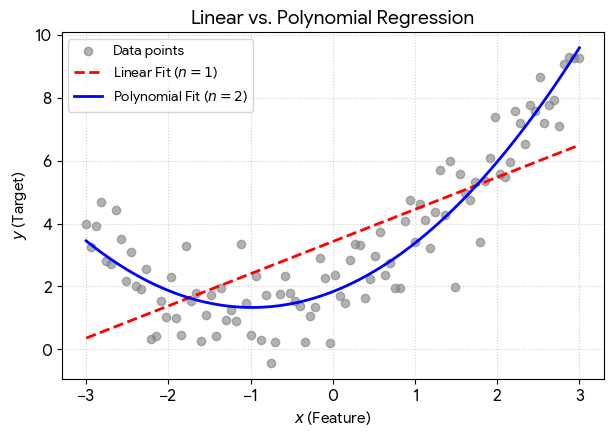

**Fexibility and Complexity**: l It does not assume all independent variables are independent. By introducing higher-degree terms, it allows for more flexibility and can model more complex, curvilinear relationships between variables.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


Text(0, 0.5, 'y dataset')

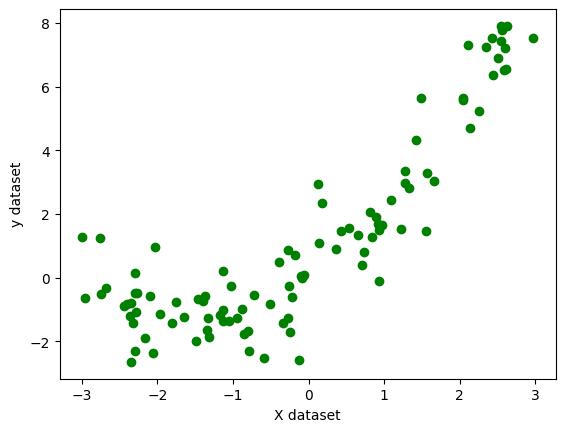

In [25]:
x=6*np.random.rand(100,1)-3
#quadratic equation used y=0.5x^2+1.5*x+outliers

y=0.5*x**2+1.5*x+np.random.randn(100,1)

plt.scatter(x,y,color='g')
plt.xlabel("X dataset")
plt.ylabel("y dataset")

In [26]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


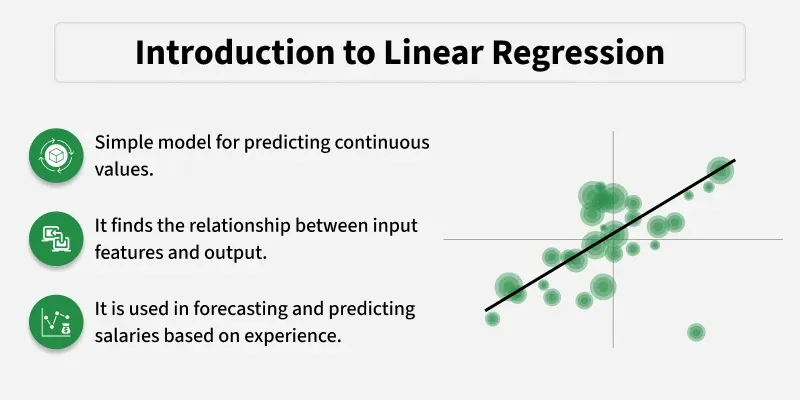

In [27]:
#lets implementr of simple linear regression
from sklearn.linear_model import  LinearRegression
regression_1=LinearRegression()
regression_1.fit(x_train,y_train)
print(score)


0.6650275551614079


In [28]:
from sklearn.metrics import r2_score
score=r2_score(y_test,regression_1.predict(x_test))
print(score)

0.5153695314886975


Text(0, 0.5, 'y Dataset')

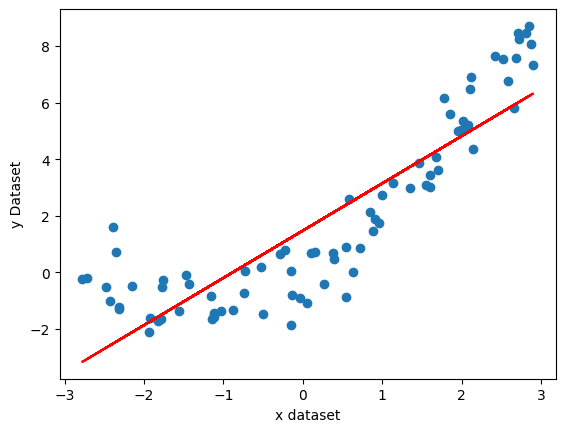

In [15]:
#let visulalizd this models
plt.plot(x_train,regression_1.predict(x_train),color='r')
plt.scatter(x_train,y_train)
plt.xlabel("x dataset")
plt.ylabel("y Dataset")



Now we will apply the polynomials transformation on this dataset

---
We use include_bias=True (or 1) to automatically add an intercept (constant term) to your dataset [1, 2].In mathematical terms, a standard linear equation looks like this:\(y=mx+c\).

Why is it used?Sets a Baseline: It allows your machine learning model to start from a baseline value instead of forcing the prediction through the origin (0,0) [1].Simplifies Modeling: Most regression models (like LinearRegression) need a bias term [1]. By generating it here, the model can calculate the intercept coefficient directly from the data matrix.


In [29]:
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=2,include_bias=True)
x_train_poly=poly.fit_transform(x_train)
x_test_poly=poly.transform(x_test)


In [30]:
from sklearn.metrics import r2_score
regression=LinearRegression()
regression.fit(x_train_poly,y_train)
y_pred=regression.predict(x_test_poly)
score=r2_score(y_test,y_pred)
print(score)

0.8121354737541967


***Here in this score value 0.8121354737541967*** .
increse our accouacy in compare to liner regression

In [31]:
print(regression.coef_)

[[0.         1.55494261 0.50256813]]


In [32]:
print(regression.intercept_)

[-0.0798511]


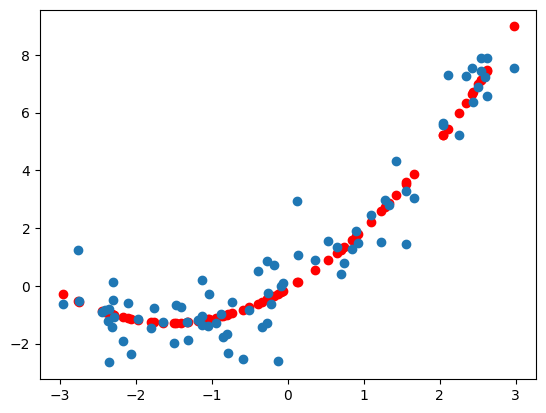

In [35]:
plt.scatter(x_train,regression.predict(x_train_poly),color='r')
plt.scatter(x_train,y_train)

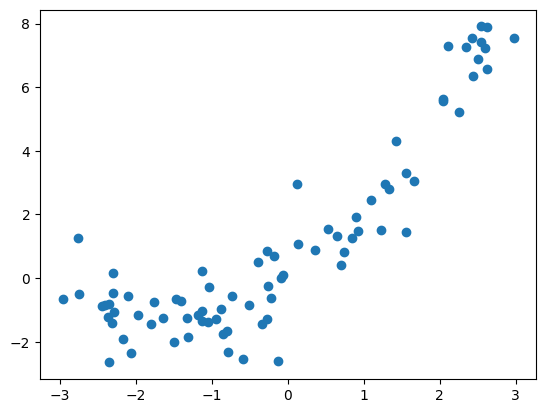

In [34]:
plt.scatter(x_train,y_train)

**What happen if we Increse the degree of Ploynomials Equation?**

In [37]:
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=4,include_bias=True)
x_train_poly=poly.fit_transform(x_train)
x_test_poly=poly.transform(x_test)


In [38]:
from sklearn.metrics import r2_score
regression=LinearRegression()
regression.fit(x_train_poly,y_train)
y_pred=regression.predict(x_test_poly)
score=r2_score(y_test,y_pred)
print(score)

0.8168582322878619


In [39]:
#Prdication for New Dataset

x_new=np.linspace(-3,3,200).reshape(200,1)
x_new_poly=poly.transform(x_new)
x_new_poly


array([[ 1.00000000e+00, -3.00000000e+00,  9.00000000e+00,
        -2.70000000e+01,  8.10000000e+01],
       [ 1.00000000e+00, -2.96984925e+00,  8.82000455e+00,
        -2.61940839e+01,  7.77924802e+01],
       [ 1.00000000e+00, -2.93969849e+00,  8.64182723e+00,
        -2.54043665e+01,  7.46811778e+01],
       [ 1.00000000e+00, -2.90954774e+00,  8.46546804e+00,
        -2.46306834e+01,  7.16641492e+01],
       [ 1.00000000e+00, -2.87939698e+00,  8.29092700e+00,
        -2.38728702e+01,  6.87394705e+01],
       [ 1.00000000e+00, -2.84924623e+00,  8.11820409e+00,
        -2.31307624e+01,  6.59052376e+01],
       [ 1.00000000e+00, -2.81909548e+00,  7.94729931e+00,
        -2.24041955e+01,  6.31595663e+01],
       [ 1.00000000e+00, -2.78894472e+00,  7.77821267e+00,
        -2.16930052e+01,  6.05005924e+01],
       [ 1.00000000e+00, -2.75879397e+00,  7.61094417e+00,
        -2.09970269e+01,  5.79264711e+01],
       [ 1.00000000e+00, -2.72864322e+00,  7.44549380e+00,
        -2.03160961e+01

1. x_new = np.linspace(-3, 3, 200).reshape(200, 1)

What it does: It creates a column of test inputs.np.linspace(-3, 3, 200): Generates an array of 200 numbers starting exactly at -3 and ending exactly at 3. The numbers are spaced evenly (e.g., -3.0, -2.97, -2.94, ..., 3.0).

.reshape(200, 1): Changes the data shape from a flat 1D row vector into a 2D column vector with 200 rows and 1 column. Scikit-learn models strictly require a 2D array structure for features.

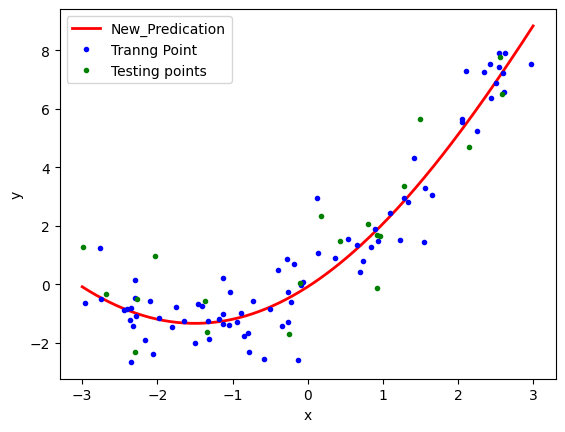

In [42]:
y_new=regression.predict(x_new_poly)
plt.plot(x_new,y_new,"r-",linewidth=2,label="New_Predication")
plt.plot(x_train,y_train,"b.",label="Tranng Point")
plt.plot(x_test,y_test,"g.",label="Testing points")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()